In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
path = "data/data.csv"

In [3]:
df = pd.read_csv(path)

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
df.shape

(4600, 18)

### Ý nghĩa các cột trong bộ dữ liệu Giá nhà (House Sales Data)

| Tên cột | Ý nghĩa | Mô tả chi tiết |
| :--- | :--- | :--- |
| **date** | Ngày bán | Thời gian căn nhà được giao dịch (YYYY-MM-DD). |
| **price** | Giá bán | Giá của căn nhà (Biến mục tiêu cần dự đoán). |
| **bedrooms** | Phòng ngủ | Số lượng phòng ngủ trong nhà. |
| **bathrooms** | Phòng tắm | Số lượng phòng tắm (ví dụ: 1.5 nghĩa là 1 phòng đầy đủ và 1 phòng vệ sinh). |
| **sqft_living** | Diện tích ở | Diện tích không gian sống bên trong căn nhà (tính bằng feet vuông). |
| **sqft_lot** | Diện tích đất | Diện tích toàn bộ lô đất bao gồm cả sân vườn. |
| **floors** | Số tầng | Số tầng của căn nhà. |
| **waterfront** | View mặt nước | 0: Không có view biển/hồ; 1: Có view mặt nước. |
| **view** | Chỉ số tầm nhìn | Đánh giá mức độ đẹp của view (từ 0 đến 4). |
| **condition** | Tình trạng | Đánh giá chất lượng hạ tầng nhà (từ 1 đến 5). |
| **sqft_above** | Diện tích nổi | Diện tích không gian sống trên mặt đất (không tính hầm). |
| **sqft_basement** | Diện tích hầm | Diện tích phần không gian sống nằm dưới tầng hầm. |
| **yr_built** | Năm xây dựng | Năm ngôi nhà được hoàn thành xây dựng lần đầu. |
| **yr_renovated** | Năm cải tạo | Năm gần nhất nhà được sửa chữa (nếu bằng 0 là chưa từng cải tạo). |
| **street** | Tên đường | Địa chỉ cụ thể của căn nhà. |
| **city** | Thành phố | Thành phố nơi căn nhà tọa lạc. |
| **statezip** | Mã bưu chính | Bao gồm tên bang (WA) và mã vùng (Zip code). |
| **country** | Quốc gia | Quốc gia của bộ dữ liệu (thường là USA). |

### Data Clearning

In [5]:
df.drop(["date", "street", "country"], inplace=True, axis=1)
df = df.drop_duplicates()
df = df.dropna()
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052


In [6]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [7]:
df.shape

(4600, 15)

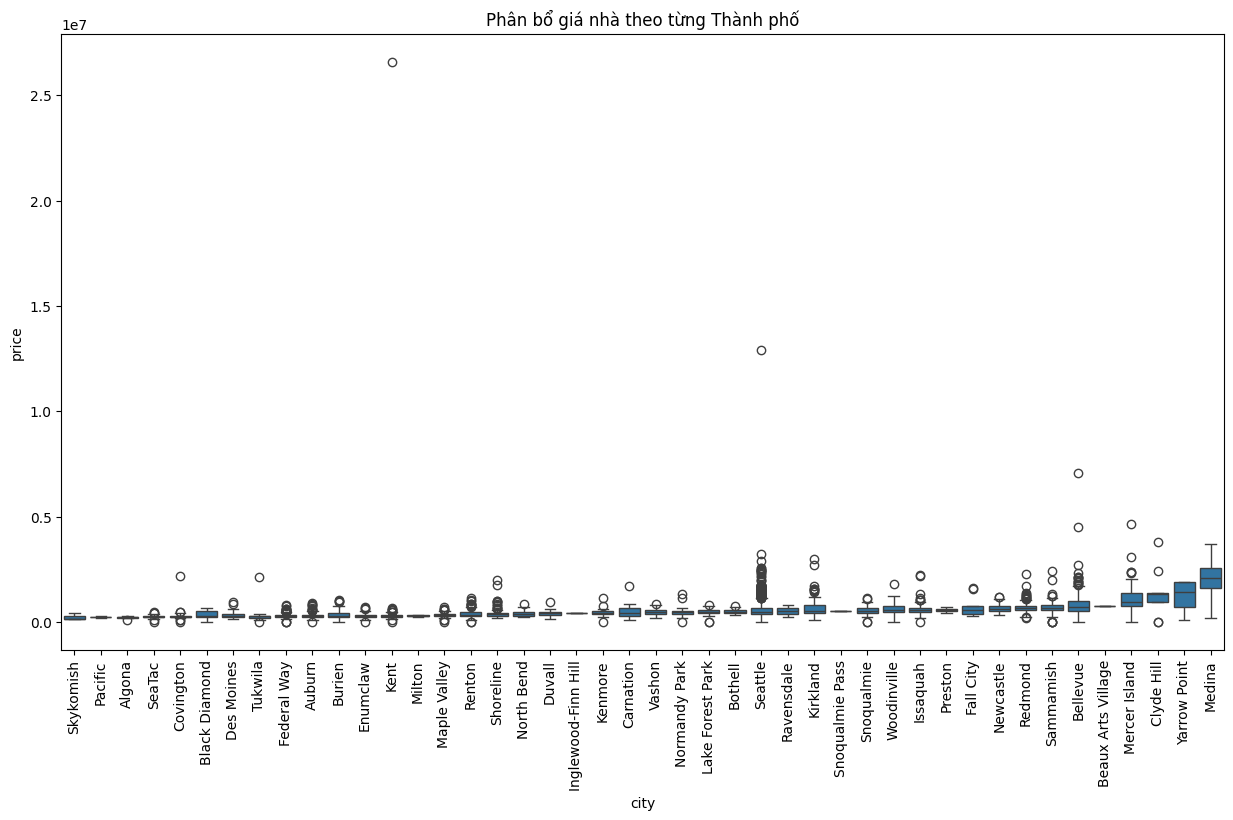

In [8]:
# quan sát biến phân loại thành phố với price để tìm cách xử lý cho biến city 

city_order = df.groupby('city')['price'].median().sort_values(ascending=True).index

plt.figure(figsize=(15, 8))
sns.boxplot(x='city', y='price', data=df, order=city_order)
plt.xticks(rotation=90)
plt.title('Phân bổ giá nhà theo từng Thành phố')
plt.show()

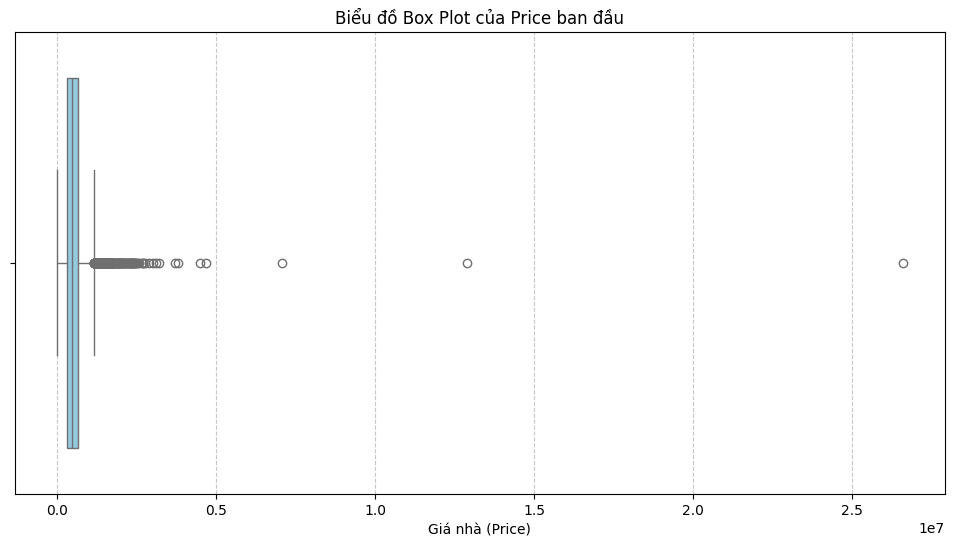

In [9]:
plt.figure(figsize=(12, 6))

# Vẽ Box plot tổng quát
sns.boxplot(x=df['price'], color='skyblue')

plt.title('Biểu đồ Box Plot của Price ban đầu')
plt.xlabel('Giá nhà (Price)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [10]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

print(f"--- Thống kê cột Price Ban đầu ---")
print(f"Q1 (25%): {Q1:,.2f}")
print(f"Q3 (75%): {Q3:,.2f}")
print(f"IQR:      {IQR:,.2f}")
print(f"Min:      {df['price'].min():,.2f}")
print(f"Max:      {df['price'].max():,.2f}")

--- Thống kê cột Price Ban đầu ---
Q1 (25%): 322,875.00
Q3 (75%): 654,962.50
IQR:      332,087.50
Min:      0.00
Max:      26,590,000.00


In [11]:
# xử lý các giá trị outlier
def get_lower_bound(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    return Q1 - 1.5 * (Q3 - Q1)

def get_upper_bound(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    return Q3 + 1.5 * IQR

df['lower_limit'] = df.groupby('city')['price'].transform(get_lower_bound)
df['upper_limit'] = df.groupby('city')['price'].transform(get_upper_bound)

df_clean = df[(df['price'] >= df['lower_limit']) & (df['price'] <= df['upper_limit'])].copy()

df_clean.drop(columns=['lower_limit', 'upper_limit'], inplace=True)
df_clean = df_clean[df_clean['price'] > 0].copy()

print(f"Số lượng dòng trước khi lọc: {len(df)}")
print(f"Số lượng dòng sau khi lọc: {len(df_clean)}")

df = df_clean

Số lượng dòng trước khi lọc: 4600
Số lượng dòng sau khi lọc: 4286


In [12]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

print(f"--- Thống kê cột Price (sau khi lọc) ---")
print(f"Q1 (25%): {Q1:,.2f}")
print(f"Q3 (75%): {Q3:,.2f}")
print(f"IQR:      {IQR:,.2f}")
print(f"Min:      {df['price'].min():,.2f}")
print(f"Max:      {df['price'].max():,.2f}")

--- Thống kê cột Price (sau khi lọc) ---
Q1 (25%): 320,000.00
Q3 (75%): 620,000.00
IQR:      300,000.00
Min:      80,000.00
Max:      3,710,000.00


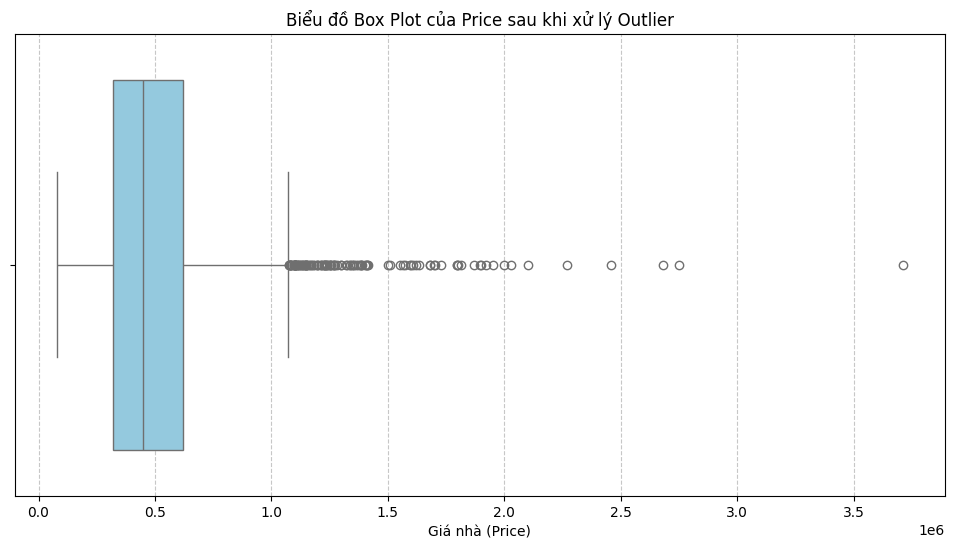

In [13]:
plt.figure(figsize=(12, 6))

# Vẽ Box plot tổng quát
sns.boxplot(x=df['price'], color='skyblue')

plt.title('Biểu đồ Box Plot của Price sau khi xử lý Outlier')
plt.xlabel('Giá nhà (Price)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

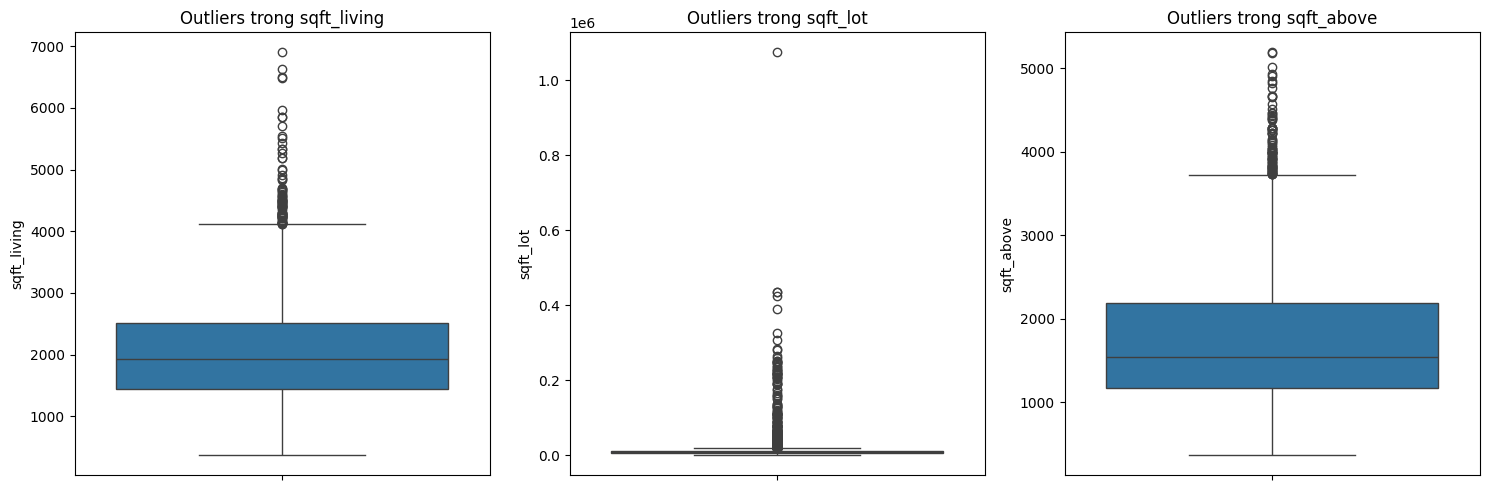

In [14]:
cols_to_check = ['sqft_living', 'sqft_lot', 'sqft_above']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers trong {col}')
plt.tight_layout()
plt.show()

In [15]:
df[['sqft_living', 'sqft_lot', 'sqft_above']].describe(percentiles=[.95, .96, .97, .98, .99]).round(2)

,sqft_living,sqft_lot,sqft_above
count,4286.00,4286.00,4286.00
mean,2034.22,13711.45,1744.40
std,818.14,32685.53,756.45
min,370.00,638.00,370.00
95%,3537.50,40238.00,3220.00
96%,3676.00,45429.20,3310.00
97%,3824.50,54450.00,3470.00
98%,4053.00,79497.10,3703.00
99%,4443.00,174417.15,4010.00
max,6900.00,1074218.00,5190.00


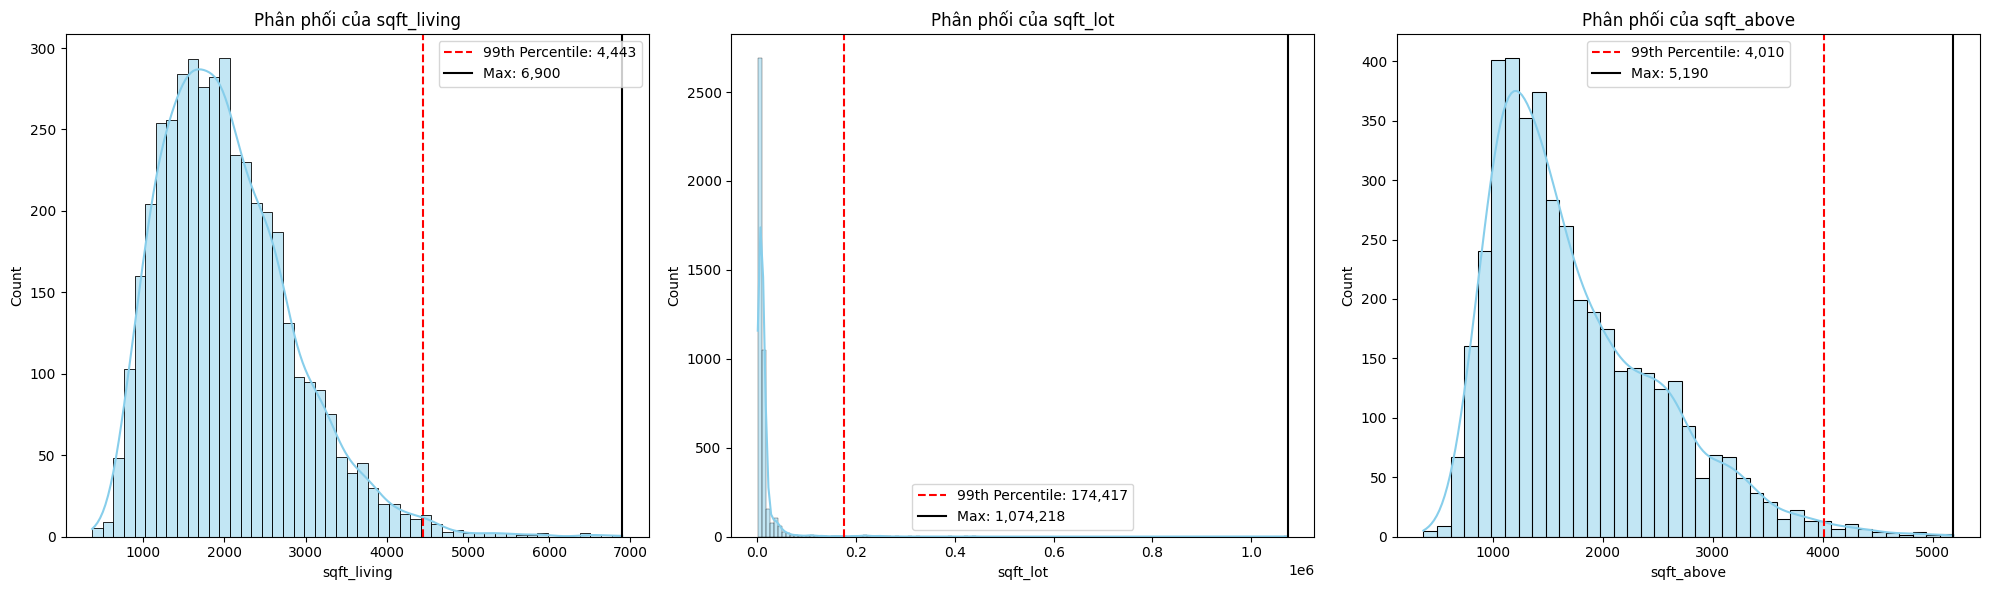

In [16]:
cols = ['sqft_living', 'sqft_lot', 'sqft_above']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    
    # Lấy các mốc giá trị
    p99 = df[col].quantile(0.99)
    v_max = df[col].max()
    
    # Vẽ đường kẻ mốc 99% và Max
    axes[i].axvline(p99, color='red', linestyle='--', label=f'99th Percentile: {p99:,.0f}')
    axes[i].axvline(v_max, color='black', linestyle='-', label=f'Max: {v_max:,.0f}')
    
    axes[i].set_title(f'Phân phối của {col}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [17]:
c_living = (df['sqft_living'] > 5500).sum()
c_lot = (df['sqft_lot'] > 200000).sum()
c_above = (df['sqft_above'] > 4500).sum()

outlier_indices = df[(df['sqft_living'] > 5500) | 
                     (df['sqft_lot'] > 200000) | 
                     (df['sqft_above'] > 4500)].index

print(f"Living > 5k5: {c_living}")
print(f"Lot > 200k: {c_lot}")
print(f"Above > 4k5: {c_above}")

total_outliers = len(outlier_indices)
total_samples = len(df)
percent_outliers = (total_outliers / total_samples) * 100

print(f"Tổng {total_outliers} mẫu dị biệt trên tổng số {total_samples} mẫu.")
print(f"Chiếm tỷ lệ {percent_outliers:.2f}% của toàn bộ tập dữ liệu.")

Living > 5k5: 10
Lot > 200k: 37
Above > 4k5: 13
Tổng 53 mẫu dị biệt trên tổng số 4286 mẫu.
Chiếm tỷ lệ 1.24% của toàn bộ tập dữ liệu.


In [18]:
# Xử lí outlier
df['sqft_living'] = df['sqft_living'].clip(upper=5500)
df['sqft_lot']    = df['sqft_lot'].clip(upper=200000)
df['sqft_above']  = df['sqft_above'].clip(upper=4500)

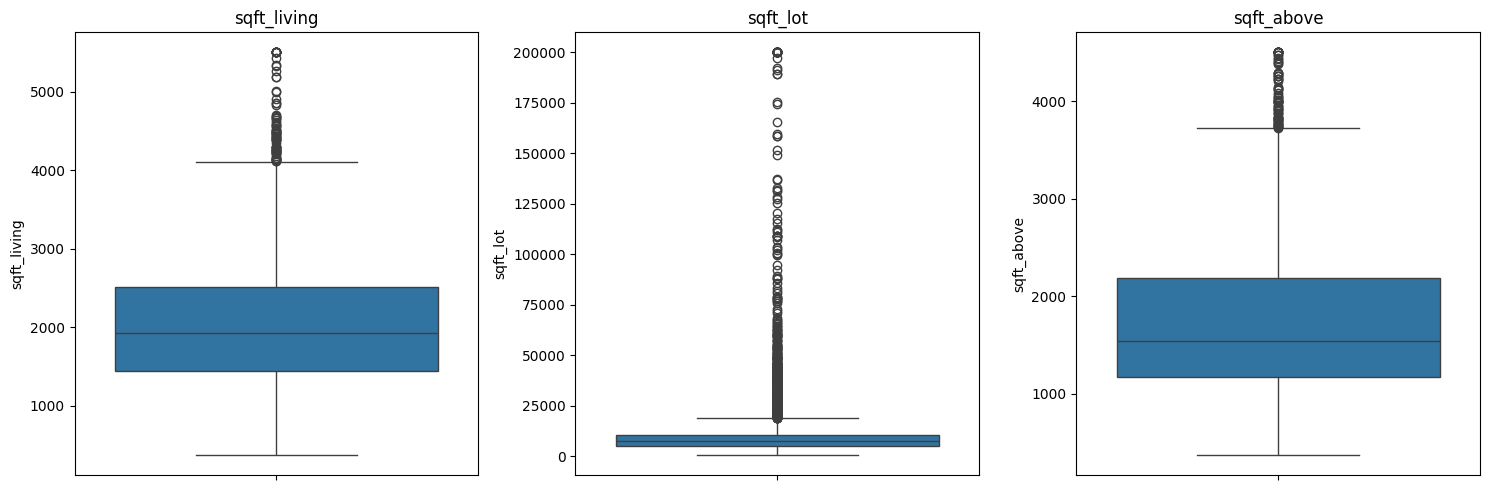

In [19]:
cols_to_check = ['sqft_living', 'sqft_lot', 'sqft_above']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'{col}')
plt.tight_layout()
plt.show()

### EDA

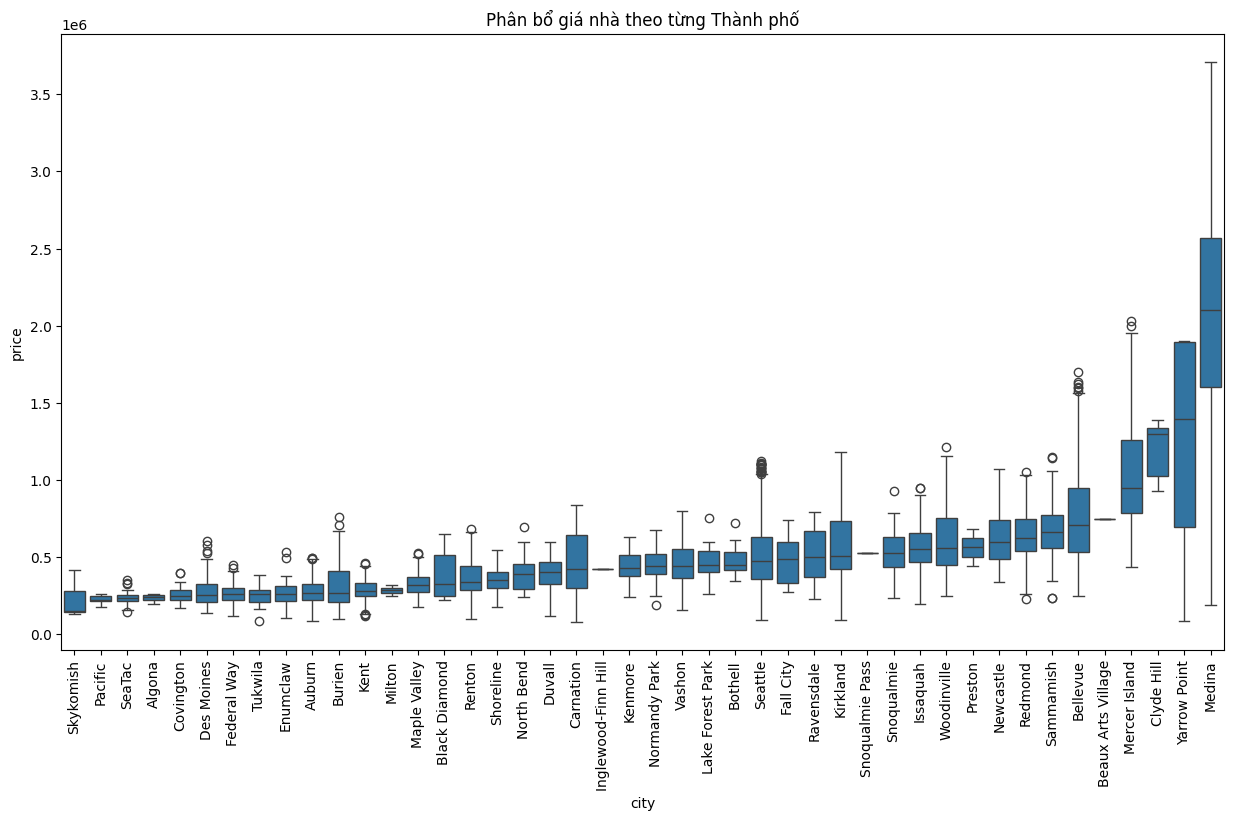

In [20]:
city_order = df.groupby('city')['price'].median().sort_values(ascending=True).index

plt.figure(figsize=(15, 8))
sns.boxplot(x='city', y='price', data=df, order=city_order)
plt.xticks(rotation=90)
plt.title('Phân bổ giá nhà theo từng Thành phố')
plt.show()

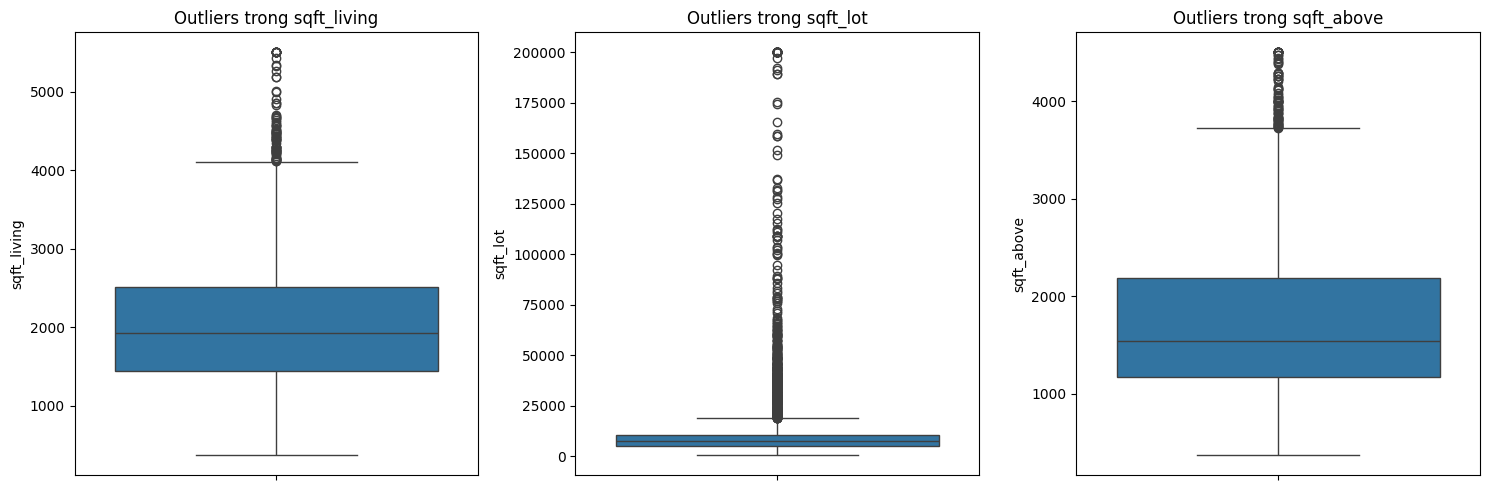

In [21]:
cols_to_check = ['sqft_living', 'sqft_lot', 'sqft_above']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers trong {col}')
plt.tight_layout()
plt.show()

In [22]:
df.describe().round(2)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4286.00,4286.00,4286.00,4286.00,4286.00,4286.00,4286.00,4286.00,4286.00,4286.00,4286.00,4286.00,4286.00
mean,501727.76,3.36,2.10,2032.83,13017.58,1.49,0.00,0.17,3.45,1743.42,289.82,1970.73,812.09
std,259122.24,0.89,0.72,811.40,23831.29,0.54,0.05,0.64,0.67,752.54,431.48,29.44,980.17
min,80000.00,0.00,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,1900.00,0.00
25%,320000.00,3.00,1.75,1440.00,5000.00,1.00,0.00,0.00,3.00,1170.00,0.00,1951.00,0.00
50%,450000.00,3.00,2.25,1920.00,7566.00,1.50,0.00,0.00,3.00,1540.00,0.00,1975.00,0.00
75%,620000.00,4.00,2.50,2510.00,10653.75,2.00,0.00,0.00,4.00,2190.00,577.50,1996.00,1999.00
max,3710000.00,9.00,5.75,5500.00,200000.00,3.50,1.00,4.00,5.00,4500.00,2850.00,2014.00,2014.00


In [23]:
# Groupby theo condition và tính trung bình cho các cột đặc trưng
condition_summary = df.groupby("condition").agg(
    avg_price=("price", "mean"),
    avg_living_area=("sqft_living", "mean"),
    avg_lot_size=("sqft_lot", "mean"),
    avg_above_area=("sqft_above", "mean"),
    house_count=("price", "count") # Thêm cột đếm để biết mỗi nhóm có bao nhiêu nhà
)
# Hiển thị kết quả
display(condition_summary)

,avg_price,avg_living_area,avg_lot_size,avg_above_area,house_count
condition,,,,,
1,366400.000000,1434.000000,20392.800000,1288.000000,5
2,263964.137931,1398.275862,33552.655172,1189.310345,29
3,501100.186609,2100.943305,12367.926893,1874.562104,2681
4,485922.620398,1913.419355,14490.648557,1549.492360,1178
5,572650.765519,1980.582697,11424.791349,1476.702290,393


In [24]:
# Groupby theo condition và tính trung bình cho các cột đặc trưng
condition_summary = df.groupby("view").agg(
    avg_price=("price", "mean"),
    avg_living_area=("sqft_living", "mean"),
    avg_lot_size=("sqft_lot", "mean"),
    avg_above_area=("sqft_above", "mean"),
    house_count=("price", "count") # Thêm cột đếm để biết mỗi nhóm có bao nhiêu nhà
)
display(condition_summary)

,avg_price,avg_living_area,avg_lot_size,avg_above_area,house_count
view,,,,,
0,481541.738107,1982.886611,12561.777272,1723.142749,3951
1,750847.208431,2484.918033,10691.639344,1872.131148,61
2,685176.222222,2546.619883,18873.953216,1974.304094,171
3,815835.810811,2824.459459,21659.527027,2086.621622,74
4,844658.172414,2837.206897,23424.379310,1997.379310,29


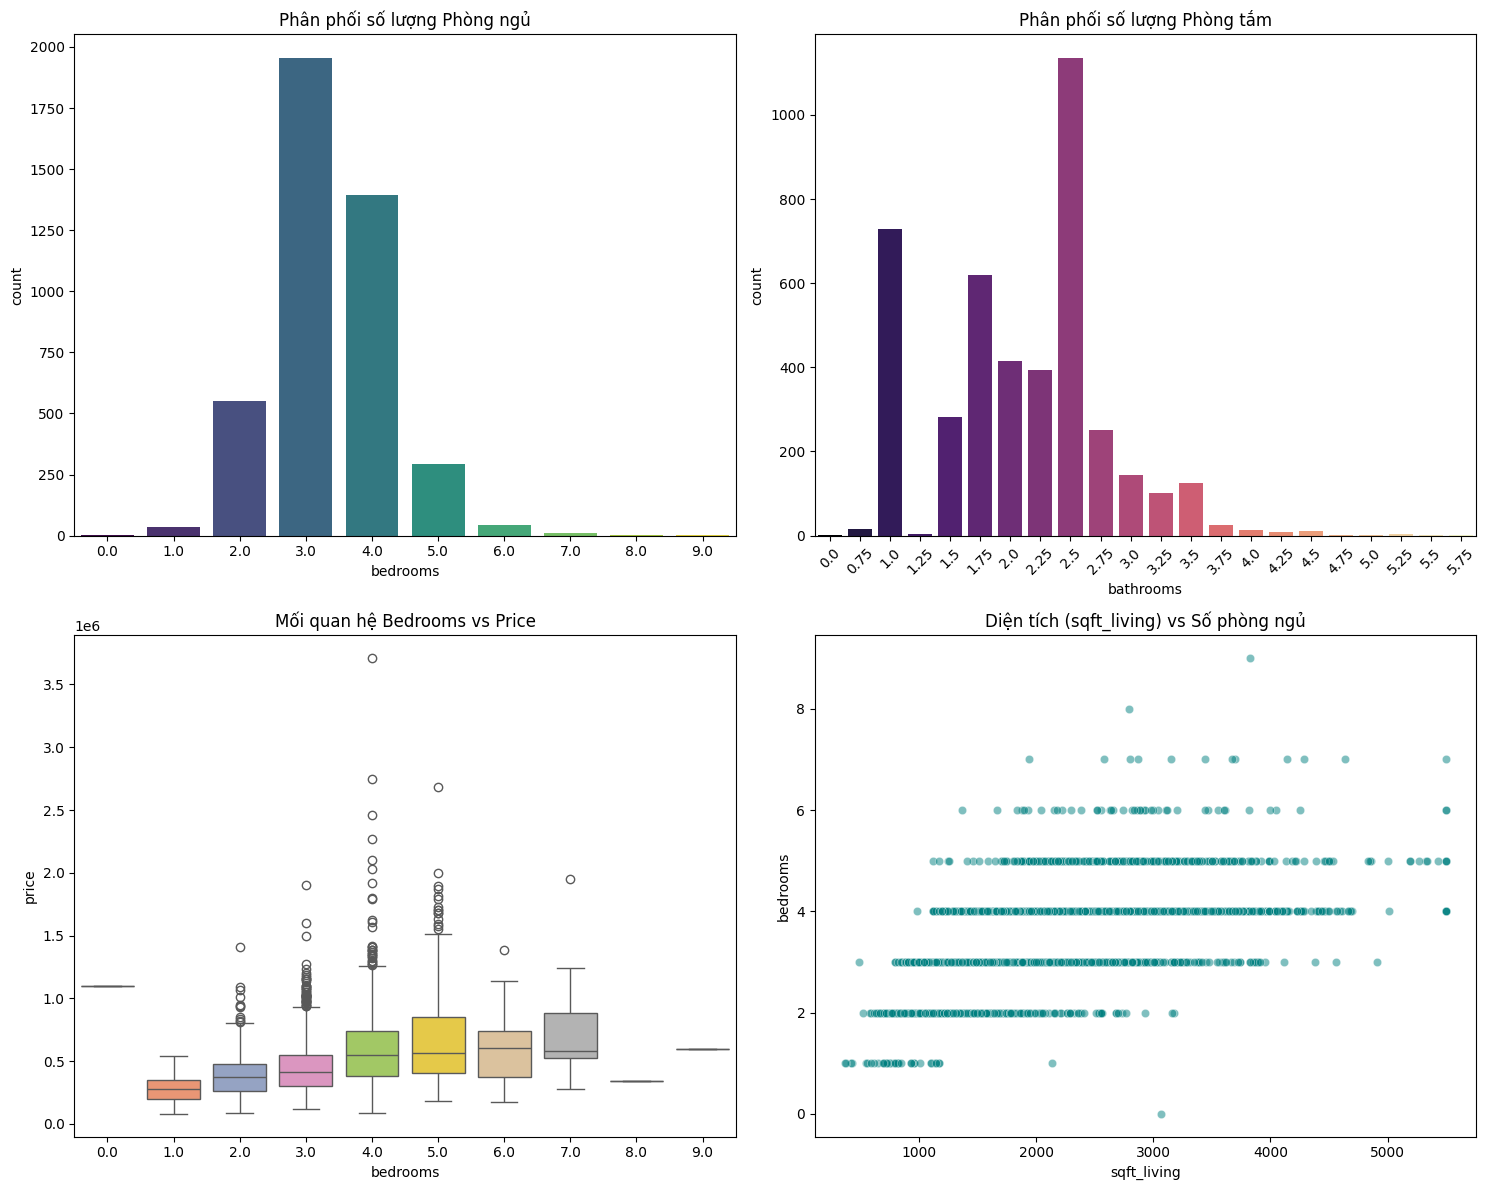

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Phân phối số lượng Phòng ngủ (Fix warning: thêm hue và legend)
sns.countplot(x='bedrooms', data=df, ax=axes[0, 0], hue='bedrooms', palette='viridis', legend=False)
axes[0, 0].set_title('Phân phối số lượng Phòng ngủ')

# 2. Phân phối số lượng Phòng tắm
sns.countplot(x='bathrooms', data=df, ax=axes[0, 1], hue='bathrooms', palette='magma', legend=False)
axes[0, 1].set_title('Phân phối số lượng Phòng tắm')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Mối quan hệ Bedrooms vs Price (Dùng boxplot để soi các điểm dị biệt)
sns.boxplot(x='bedrooms', y='price', data=df, ax=axes[1, 0], palette='Set2', hue='bedrooms', legend=False)
axes[1, 0].set_title('Mối quan hệ Bedrooms vs Price')

# 4. Sqft_living vs Bedrooms (Scatter plot xem sự logic của diện tích và số phòng)
sns.scatterplot(x='sqft_living', y='bedrooms', data=df, ax=axes[1, 1], alpha=0.5, color='teal')
axes[1, 1].set_title('Diện tích (sqft_living) vs Số phòng ngủ')

plt.tight_layout()
plt.show()

- Dữ liệu quá ít: Bạn nhìn biểu đồ Countplot (phía trên bên trái), số lượng nhà 7, 8, 9 phòng ngủ chỉ đếm trên đầu ngón tay. Mô hình không thể học tốt từ vài mẫu đơn lẻ này.
- Giá trị sử dụng đặc thù: Những căn 8-9 phòng ngủ với diện tích chỉ khoảng 3000 $ft^2$ thường là nhà cho thuê giá rẻ hoặc nhà tập thể, nên giá bán thực tế không hề cao.

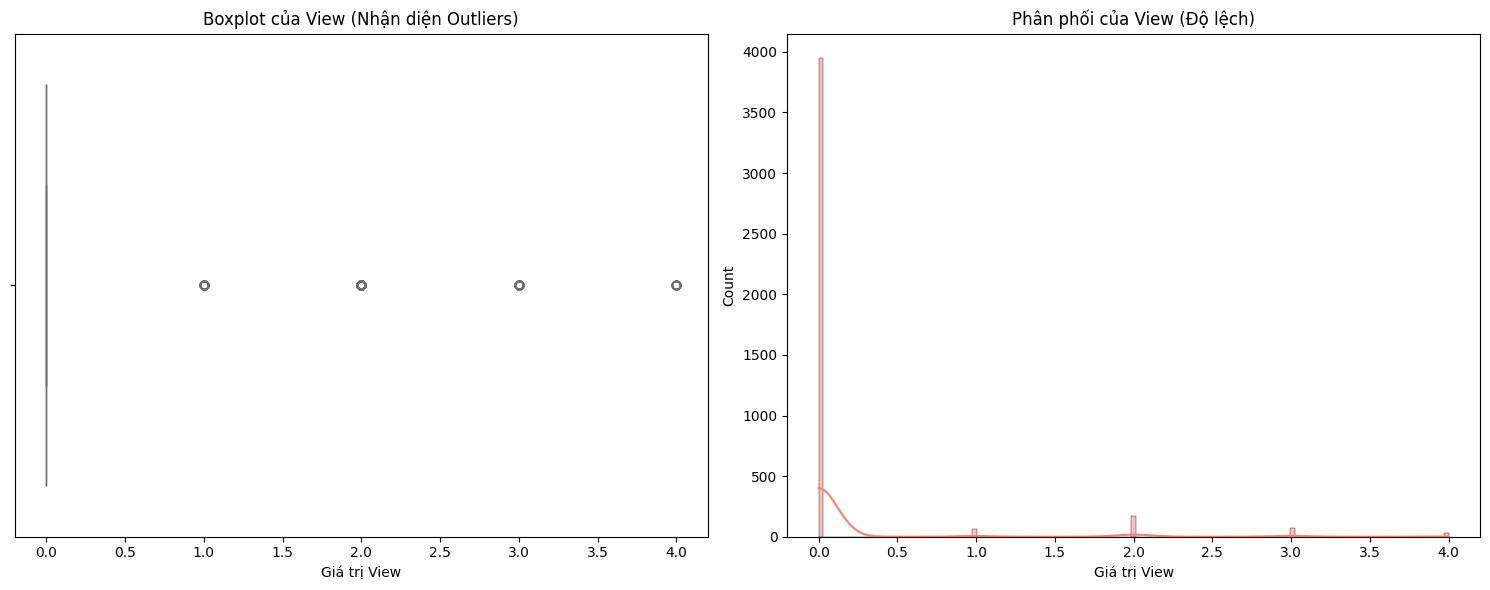

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Boxplot để thấy rõ các điểm outliers nằm ngoài khoảng quartiles
sns.boxplot(x=df['view'], ax=ax1, color='skyblue')
ax1.set_title('Boxplot của View (Nhận diện Outliers)')
ax1.set_xlabel('Giá trị View')

# 2. Histogram để xem phân phối bị lệch như thế nào
sns.histplot(df['view'], kde=True, ax=ax2, color='salmon')
ax2.set_title('Phân phối của View (Độ lệch)')
ax2.set_xlabel('Giá trị View')

plt.tight_layout()
plt.show()

In [27]:
view_counts = df['view'].value_counts().sort_index()

waterfront_counts = df['waterfront'].value_counts().sort_index()

print("--- Thống kê biến VIEW ---")
print(view_counts)
print("\n--- Thống kê biến WATERFRONT ---")
print(waterfront_counts)

--- Thống kê biến VIEW ---
view
0    3951
1      61
2     171
3      74
4      29
Name: count, dtype: int64

--- Thống kê biến WATERFRONT ---
waterfront
0    4276
1      10
Name: count, dtype: int64


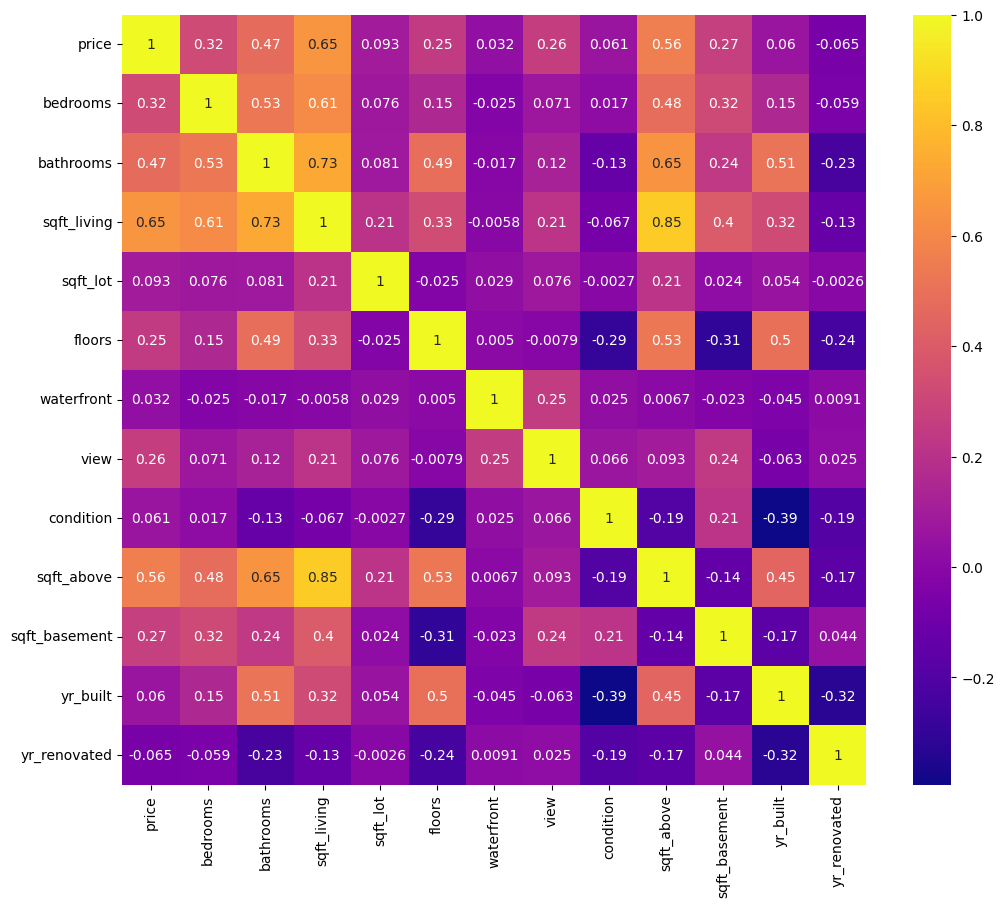

In [28]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='plasma')
plt.show()

### Feature Engineering

In [29]:
class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        
    def fit(self, X):
        X_array = np.asarray(X)
        # Tính trung bình và độ lệch chuẩn theo từng cột
        self.mean_ = np.mean(X_array, axis=0)
        self.std_ = np.std(X_array, axis=0)
        # Tránh lỗi khi chia cho 0
        self.std_[self.std_==0] = 1e-9
        return self
        
    def transform(self, X):
        X_array = np.asarray(X)
        # Áp dụng công thức: (X - mean) / std
        return (X_array - self.mean_) / self.std_
         
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [30]:
# Xử lí nốt outlier của bedroom và batroom
df = df[df['bedrooms'] > 0]
df['bedrooms'] = df['bedrooms'].clip(upper=7)

df = df[df['bathrooms'] > 0]
df['bathrooms'] = df['bathrooms'].clip(upper=4.5)

In [31]:
df["statezip"].unique()

<ArrowStringArray>
['WA 98133', 'WA 98042', 'WA 98008', 'WA 98052', 'WA 98115', 'WA 98038',
 'WA 98045', 'WA 98155', 'WA 98074', 'WA 98106', 'WA 98007', 'WA 98092',
 'WA 98198', 'WA 98006', 'WA 98102', 'WA 98011', 'WA 98125', 'WA 98003',
 'WA 98136', 'WA 98033', 'WA 98029', 'WA 98117', 'WA 98034', 'WA 98072',
 'WA 98107', 'WA 98166', 'WA 98116', 'WA 98024', 'WA 98055', 'WA 98077',
 'WA 98027', 'WA 98059', 'WA 98075', 'WA 98014', 'WA 98065', 'WA 98199',
 'WA 98053', 'WA 98058', 'WA 98122', 'WA 98103', 'WA 98112', 'WA 98005',
 'WA 98118', 'WA 98177', 'WA 98105', 'WA 98023', 'WA 98004', 'WA 98019',
 'WA 98119', 'WA 98144', 'WA 98168', 'WA 98001', 'WA 98056', 'WA 98146',
 'WA 98028', 'WA 98148', 'WA 98057', 'WA 98040', 'WA 98010', 'WA 98051',
 'WA 98031', 'WA 98030', 'WA 98126', 'WA 98032', 'WA 98178', 'WA 98288',
 'WA 98108', 'WA 98070', 'WA 98109', 'WA 98188', 'WA 98002', 'WA 98039',
 'WA 98022', 'WA 98068', 'WA 98047', 'WA 98050', 'WA 98354']
Length: 77, dtype: str

In [32]:
current_year = 2026 
df['house_age'] = current_year - df['yr_built']

df['has_basement'] = (df['sqft_basement'] > 0).astype(int)
# Features yr_renovated chuyển về binary đã từng được fix chưa
df["is_renovated"] = df['yr_renovated'].apply(lambda x: 1 if x>0 else 0)

In [33]:
area_cols = ['sqft_living', 'sqft_above', 'sqft_lot']
for col in area_cols:
    df[col] = np.log1p(df[col])

In [34]:
df['avg_room_size'] = df['sqft_living'] / (df['bedrooms'] + df['bathrooms'])

In [35]:
df['total_quality'] = df['view'] + df['condition']

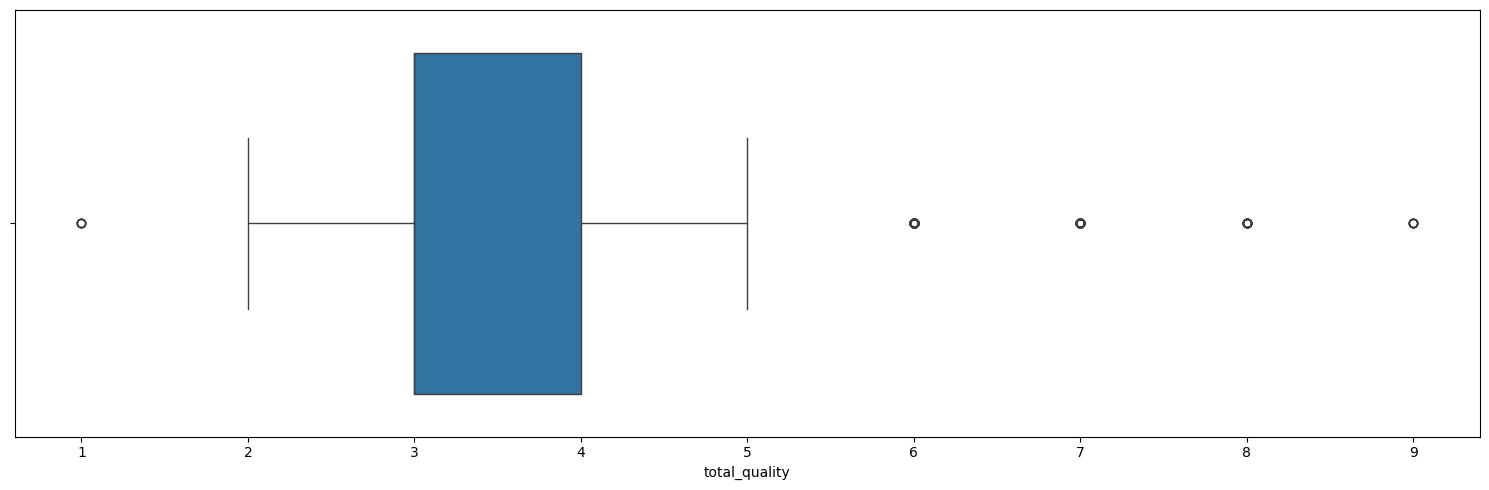

In [55]:
plt.figure(figsize=(15, 5))

sns.boxplot(x=df['total_quality'])
plt.tight_layout()
plt.show()

In [37]:
features_cols = [        
    'avg_room_size',    
    'house_age',        
    'total_quality',
    'is_renovated',
    'has_basement',    
    'sqft_living', 
    'sqft_above', 
    'sqft_lot',
    'statezip',
    'city'
]

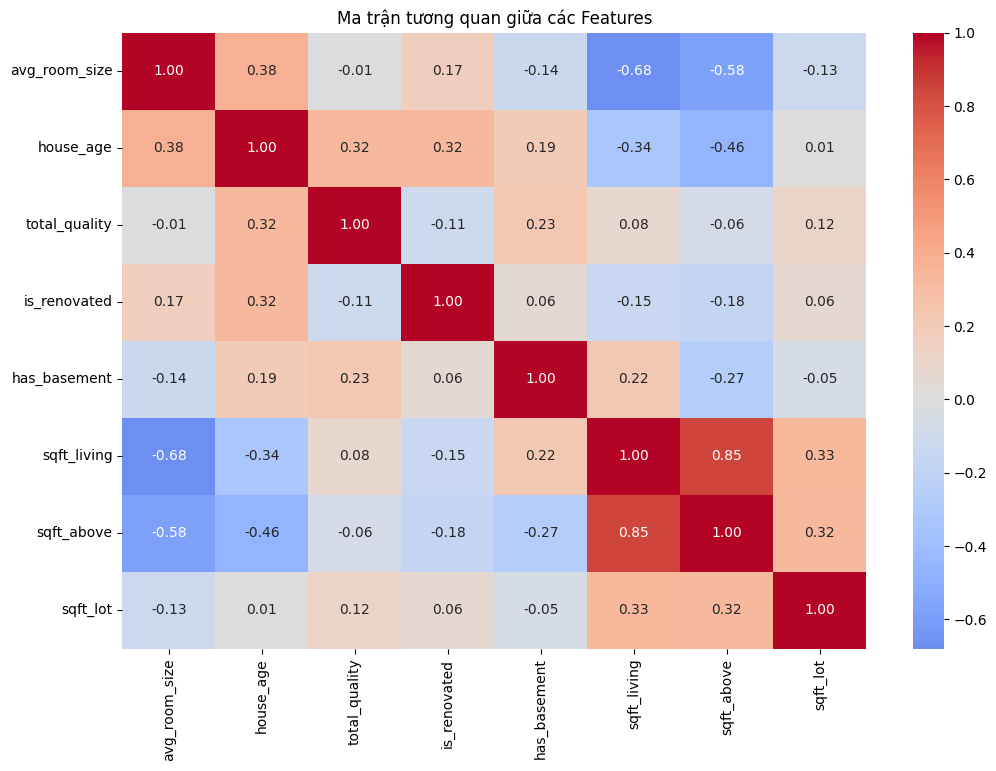

In [38]:
plt.figure(figsize=(12, 8))
corr_matrix = df[features_cols].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Ma trận tương quan giữa các Features")
plt.show()

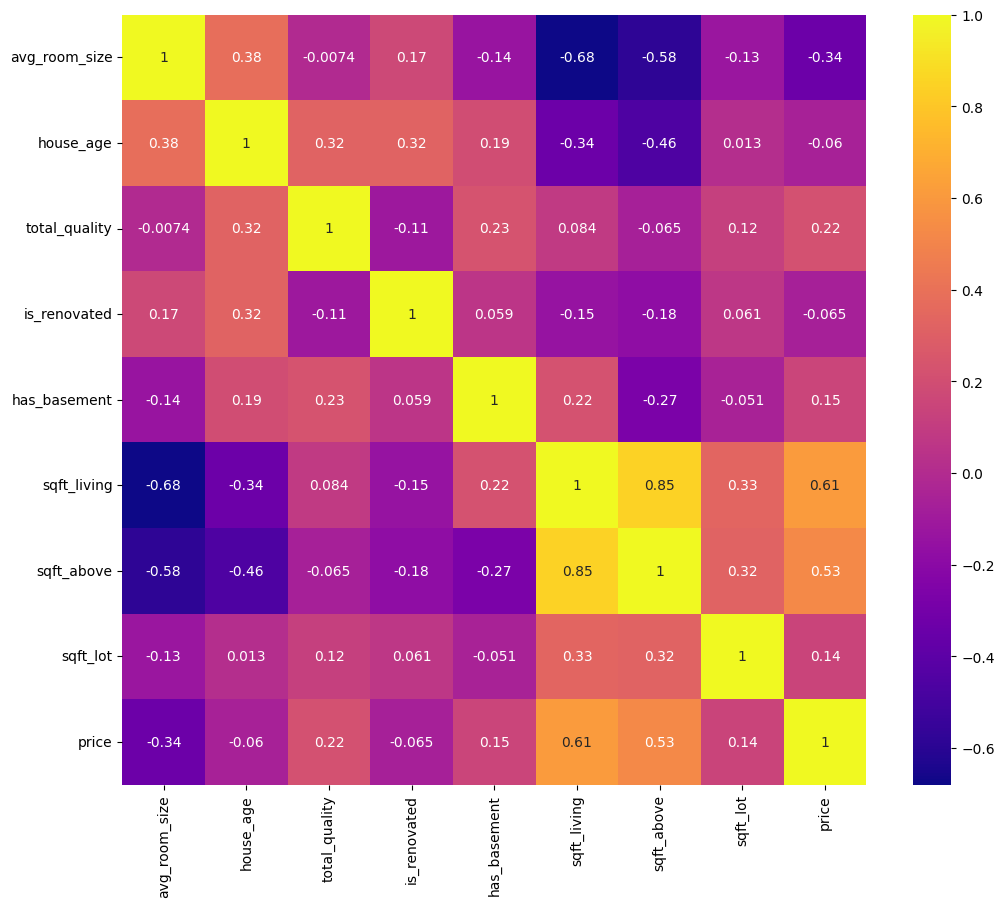

In [39]:
check_cols = [        
    'avg_room_size',    
    'house_age',        
    'total_quality',
    'is_renovated',
    'has_basement',    
    'sqft_living', 
    'sqft_above', 
    'sqft_lot',
    'statezip',
    'city',
    'price'
]
plt.figure(figsize=(12, 10))
sns.heatmap(df[check_cols].select_dtypes(include='number').corr(), annot=True, cmap='plasma')
plt.show()

In [40]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,house_age,has_basement,is_renovated,avg_room_size,total_quality
count,4.285000e+03,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000,4285.000000
mean,5.015893e+05,3.359860,2.095391,7.538624,8.962094,1.494282,0.002334,0.172462,3.449242,7.377931,289.887748,1970.729755,811.809568,55.270245,0.393232,0.407001,1.471075,3.621704
std,2.589939e+05,0.880738,0.710925,0.403332,0.876986,0.535637,0.048258,0.637959,0.671935,0.411876,431.506497,29.446216,980.110676,29.446216,0.488525,0.491332,0.380691,0.956791
min,8.000000e+04,1.000000,0.750000,5.916202,6.459904,1.000000,0.000000,0.000000,1.000000,5.916202,0.000000,1900.000000,0.000000,12.000000,0.000000,0.000000,0.714466,1.000000
25%,3.200000e+05,3.000000,1.750000,7.273093,8.517393,1.000000,0.000000,0.000000,3.000000,7.065613,0.000000,1951.000000,0.000000,30.000000,0.000000,0.000000,1.212722,3.000000
50%,4.500000e+05,3.000000,2.250000,7.560601,8.931552,1.500000,0.000000,0.000000,3.000000,7.340187,0.000000,1975.000000,0.000000,51.000000,0.000000,0.000000,1.394369,3.000000
75%,6.200000e+05,4.000000,2.500000,7.828436,9.273878,2.000000,0.000000,0.000000,4.000000,7.692113,580.000000,1996.000000,1999.000000,75.000000,1.000000,1.000000,1.603550,4.000000
max,3.710000e+06,7.000000,4.500000,8.612685,12.206078,3.500000,1.000000,4.000000,5.000000,8.412055,2850.000000,2014.000000,2014.000000,126.000000,1.000000,1.000000,4.037493,9.000000


### Data processing

In [41]:
X = df[features_cols]
y = df['price']

In [42]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train , X_val , y_train , y_val = train_test_split(X_temp,y_temp, test_size=0.1765, random_state=42) # 0.1765 * 0.85 ≈ 0.15

print(f"Tổng số mẫu: {len(df)}")
print(f"Số mẫu tập Train:      {len(X_train)} ({len(X_train)/len(df):.1%})")
print(f"Số mẫu tập Validation: {len(X_val)} ({len(X_val)/len(df):.1%})")
print(f"Số mẫu tập Test:       {len(X_test)} ({len(X_test)/len(df):.1%})")

print("Kích thước ma trận Train:      ", X_train.shape)
print("Kích thước ma trận Validation: ", X_val.shape)
print("Kích thước ma trận Test:       ", X_test.shape)

Tổng số mẫu: 4285
Số mẫu tập Train:      2999 (70.0%)
Số mẫu tập Validation: 643 (15.0%)
Số mẫu tập Test:       643 (15.0%)
Kích thước ma trận Train:       (2999, 10)
Kích thước ma trận Validation:  (643, 10)
Kích thước ma trận Test:        (643, 10)


In [43]:
from sklearn.model_selection import KFold

cat_cols = ['city', 'statezip']
kf = KFold(n_splits=5, shuffle=True, random_state=42)
global_mean = y_train.mean()

for col in cat_cols:
		X_train[col + '_target'] = np.nan

		for train_idx, val_idx in kf.split(X_train):
			X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
			y_tr = y_train.iloc[train_idx]

			temp = X_tr.copy()
			temp['price'] = y_tr
			mean_map = temp.groupby(col)['price'].mean() 
			X_train.iloc[val_idx, X_train.columns.get_loc(col + '_target')] = X_val_fold[col].map(mean_map)

		X_train[col + '_target'] = X_train[col + '_target'].fillna(global_mean)

for col in cat_cols:
	mean_map = X_train.groupby(col)[col + '_target'].mean()

	X_val[col + '_target'] = X_val[col].map(mean_map)
	X_val[col + '_target'] = X_val[col + '_target'].fillna(global_mean)

	X_test[col + '_target'] = X_test[col].map(mean_map) 
	X_test[col + '_target'] = X_test[col + '_target'].fillna(global_mean)

X_train = X_train.drop(columns=cat_cols)
X_val = X_val.drop(columns=cat_cols)
X_test = X_test.drop(columns=cat_cols)

In [44]:
X_train.head()

,avg_room_size,house_age,total_quality,is_renovated,has_basement,sqft_living,sqft_above,sqft_lot,city_target,statezip_target
4135,1.013257,25,3,0,1,8.612685,8.412055,9.614938,1.914164e+06,1.914164e+06
4046,1.059313,58,4,0,1,7.944847,7.346655,9.145909,7.804764e+05,8.078192e+05
434,1.572198,39,5,0,1,7.467942,7.170888,9.336180,6.744923e+05,6.370293e+05
3091,1.197483,36,3,1,0,7.783641,7.783641,8.902728,5.611917e+05,5.820321e+05
126,1.216745,98,5,1,0,7.300473,7.300473,8.254529,5.017962e+05,3.683650e+05


In [45]:
Cols_scale = [ 
    'avg_room_size',    
    'house_age',        
    'total_quality',  
    'sqft_living', 
    'sqft_above', 
    'sqft_lot',
    'city_target',
    'statezip_target'
]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[Cols_scale] = scaler.fit_transform(X_train[Cols_scale])
X_val[Cols_scale] = scaler.transform(X_val[Cols_scale])
X_test[Cols_scale] = scaler.transform(X_test[Cols_scale])

In [46]:
print(X_train.describe().round(2))

       avg_room_size  house_age  total_quality  is_renovated  has_basement  \
count        2999.00    2999.00        2999.00       2999.00       2999.00   
mean           -0.00       0.00           0.00          0.41          0.39   
std             1.00       1.00           1.00          0.49          0.49   
min            -2.00      -1.46          -2.77          0.00          0.00   
25%            -0.68      -0.85          -0.64          0.00          0.00   
50%            -0.20      -0.15          -0.64          0.00          0.00   
75%             0.36       0.66           0.42          1.00          1.00   
max             6.83       2.38           5.72          1.00          1.00   

       sqft_living  sqft_above  sqft_lot  city_target  statezip_target  
count      2999.00     2999.00   2999.00      2999.00          2999.00  
mean         -0.00       -0.00     -0.00         0.00            -0.00  
std           1.00        1.00      1.00         1.00             1.00  
min  

In [47]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

y_train_log = np.log1p(y_train.values)
y_val_log = np.log1p(y_val.values)
y_test_log = np.log1p(y_test.values)

y_train_tensor = torch.FloatTensor(y_train_log).view(-1, 1)
y_val_tensor = torch.FloatTensor(y_val_log).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test_log).view(-1, 1)

In [48]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Model Neural Network

In [49]:
import numpy as np

def compute_mse(y, y_pred):
    return np.mean((y-y_pred) ** 2)

def compute_mae(y, y_pred):
    return np.mean(np.abs(y-y_pred))

def compute_mape(y, y_pred):
    return 100 * np.mean(np.abs(y-y_pred) / y)

def compute_r2(y, y_pred):
    ss_res = np.mean((y - y_pred) ** 2)
    ss_tot = np.mean((y - np.mean(y)) ** 2)
        
    return 1 - (ss_res / ss_tot)

def regression_report(y, y_pred):
    mae = compute_mae(y, y_pred)
    mse = compute_mse(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = compute_r2(y, y_pred)
    mape = compute_mape(y, y_pred)

    print("Regression Report")
    print("------------------")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}")

In [50]:
class HousePriceNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            
            nn.Linear(64, 32),
            nn.LeakyReLU(),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.net(x)

In [51]:
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

input_dim = X_train_tensor.shape[1]
model = HousePriceNN(input_dim)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.05, weight_decay=1e-3)

In [52]:
num_epochs = 500
warmup_epochs = 10
scheduler_warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_epochs)

scheduler_decay = CosineAnnealingLR(optimizer, T_max=(num_epochs - warmup_epochs))

scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_epochs])
train_losses = []
val_losses = []

best_loss = float('inf')
best_model_weights = None

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        total_train_loss += loss.item()

    scheduler.step()
    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        import copy
        best_model_weights = copy.deepcopy(model.state_dict()) 
        
    # In kết quả mỗi 50 epoch
    if (epoch + 1) % 50 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.4f}")

KeyboardInterrupt: 

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_log = model(X_test_tensor).numpy()
    y_true_log = y_test_tensor.numpy()
    
# Chuyển ngược từ log1p sang giá gốc
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

regression_report(y_true, y_pred)

# In thử 5 dự đoán đầu tiên
print("\nSo sánh 5 mẫu đầu tiên:")
for i in range(5):
    print(f"Thực tế: {y_true[i][0]:10,.0f} - Dự đoán: {y_pred[i][0]:10,.0f} | Sai số: {abs(y_true[i][0]-y_pred[i][0]):,.0f}")

Regression Report
------------------
MAE  : 76119.2891
MSE  : 15012451328.0000
RMSE : 122525.3125
R2   : 0.7636
MAPE : 15.0295

So sánh 5 mẫu đầu tiên:
Thực tế:    266,000 - Dự đoán:    280,500 | Sai số: 14,500
Thực tế:    725,000 - Dự đoán:    728,911 | Sai số: 3,911
Thực tế:    360,000 - Dự đoán:    309,526 | Sai số: 50,474
Thực tế:    500,000 - Dự đoán:    611,196 | Sai số: 111,196
Thực tế:    780,000 - Dự đoán:    800,628 | Sai số: 20,628


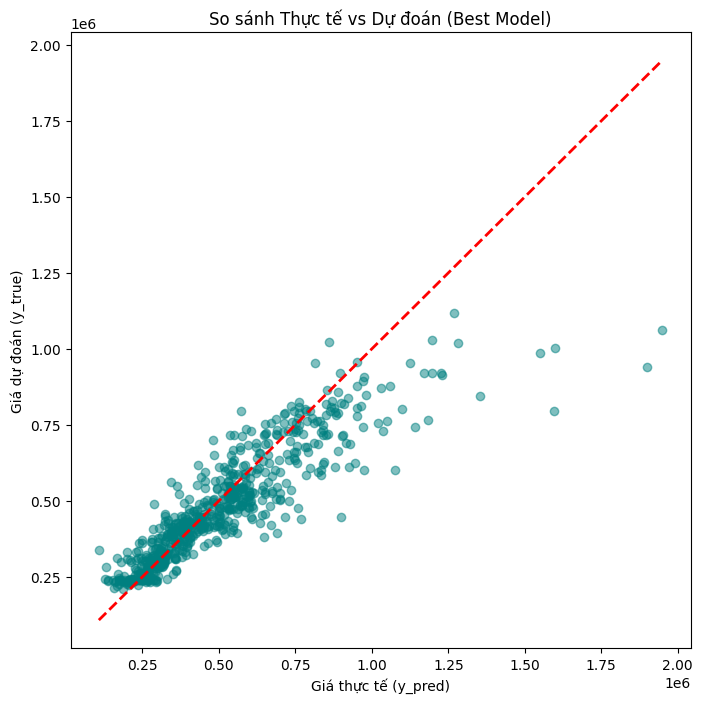

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.5, color='teal')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel('Giá thực tế (y_pred)')
plt.ylabel('Giá dự đoán (y_true)')
plt.title('So sánh Thực tế vs Dự đoán (Best Model)')
plt.show()